In [1]:
import pickle
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import tensorflow as tf

2026-02-19 19:32:30.987045: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Load embeddings
with open("/Users/jein/env/env/Fashion_product_intelligence/model/image_embeddings.pkl", "rb") as f:
    embeddings, image_paths = pickle.load(f)

print("Embeddings loaded:", embeddings.shape)


Embeddings loaded: (18603, 128)


In [3]:
# Load feature extractor again
model = tf.keras.models.load_model("/Users/jein/env/env/Fashion_product_intelligence/model/classifier_model_clean.h5")
feature_extractor = tf.keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

In [4]:
# Choose a query image
query_image_path = image_paths[0]  # or change manually

img = image.load_img(query_image_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

query_embedding = feature_extractor.predict(img_array, verbose=0)

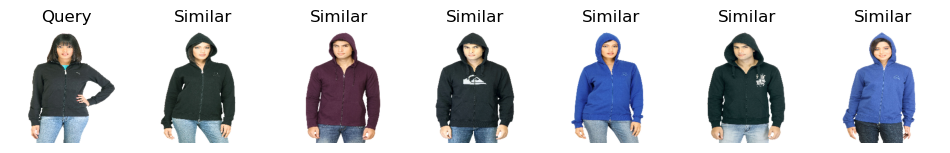

In [5]:

# Compute similarity
similarity = cosine_similarity(query_embedding, embeddings)[0]

# Get top-6 similar images (excluding itself)
top_indices = similarity.argsort()[-7:-1][::-1]

# Show results
plt.figure(figsize=(12, 6))

plt.subplot(1, 7, 1)
plt.imshow(img)
plt.title("Query")
plt.axis("off")

for i, idx in enumerate(top_indices):
    rec_img = image.load_img(image_paths[idx], target_size=(224, 224))
    plt.subplot(1, 7, i + 2)
    plt.imshow(rec_img)
    plt.title("Similar")
    plt.axis("off")

plt.show()
